In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split

In [8]:
df = pd.read_csv('C:\\Users\\aniru\\globel\\global-mobility-analyzer\\dataset\\EDA_data.csv')

## Feature Engineering / Data Pre-processing

### Outlier Check

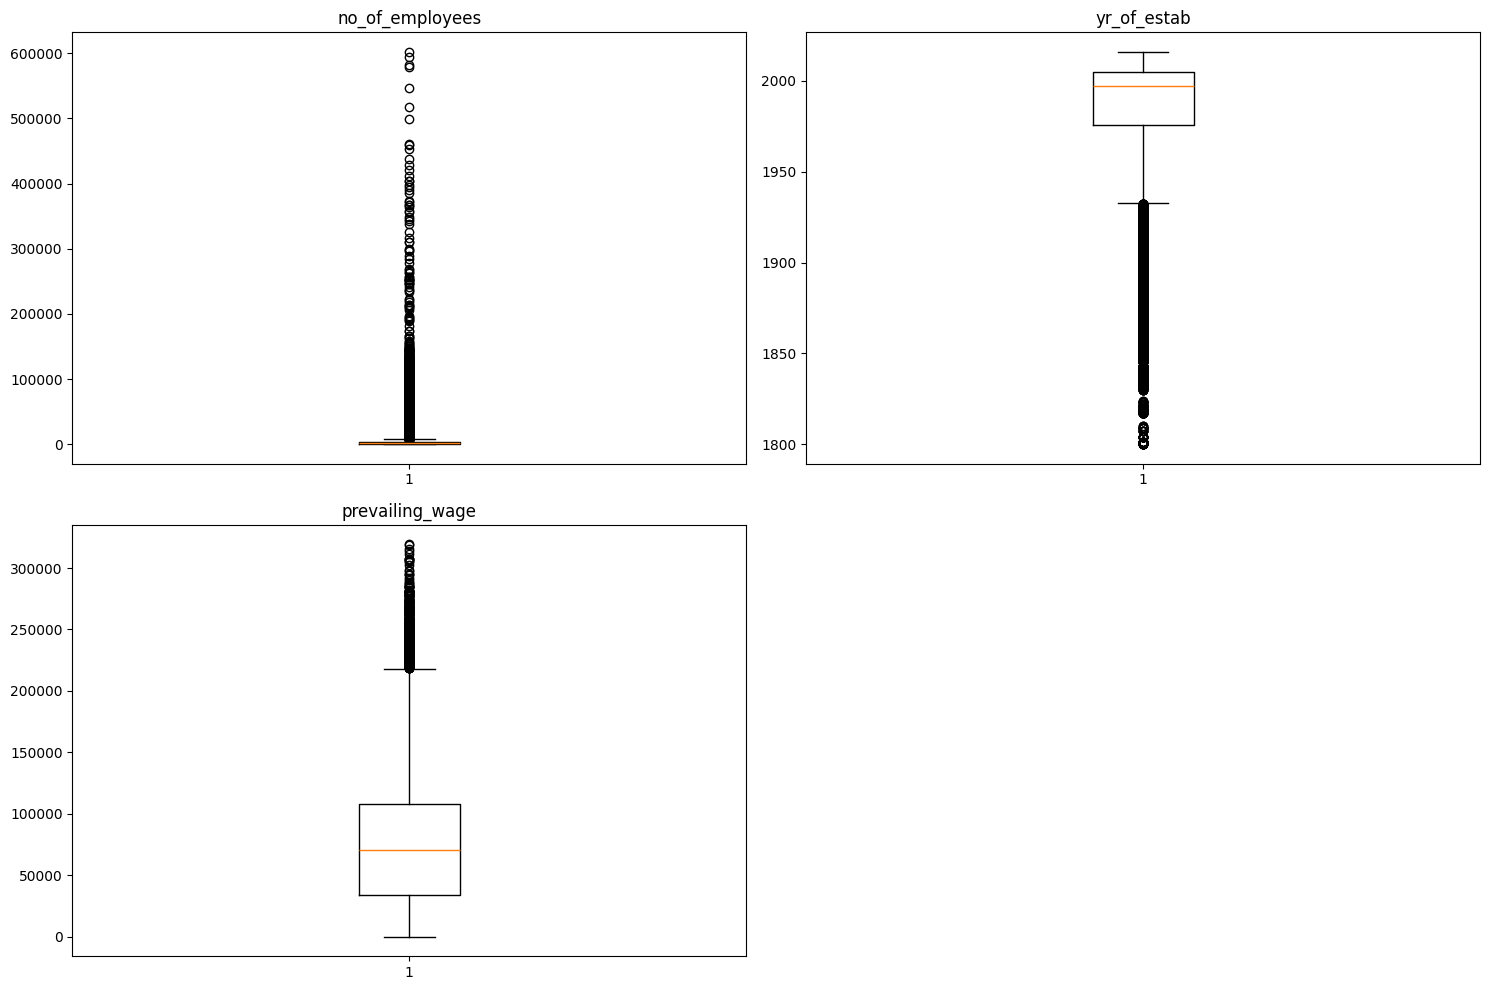

In [9]:
# Outlier detection with boxplots for numeric columns
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(15, 10))
for i, variable in enumerate(numeric_columns, start=1):
    plt.subplot(2, 2, i)
    plt.boxplot(df[variable], whis=1.5)
    plt.title(variable)
    plt.tight_layout()

plt.show()

Although there are outliers, we will keep them as they have a valuable input

Data Preparation for modeling

We want to predict which visa will be certified.

Before we proceed to build a model, we'll have to encode categorical features.

We'll split the data into train and test to be able to evaluate the model that we build on the train data.

In [10]:
# encode case status, where certified is 1, denied is 0
df["case_status"] = df["case_status"].apply(lambda x: 1 if x == "Certified" else 0)

In [20]:
# split to train and test
X = df.drop(["case_status"], axis=1)
Y = df["case_status"]

# create dummy varialbes for categories
X = pd.get_dummies(X, drop_first=True)

In [21]:
# Splitting data in train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.30, random_state=1, stratify=Y
)

In [22]:
print("Shape of Training set : ", X_train.shape)
print("Shape of test set : ", X_test.shape)
print("Percentage of classes in training set:")
print(y_train.value_counts(normalize=True))
print("Percentage of classes in test set:")
print(y_test.value_counts(normalize=True))

Shape of Training set :  (17836, 21)
Shape of test set :  (7644, 21)
Percentage of classes in training set:
case_status
1    0.667919
0    0.332081
Name: proportion, dtype: float64
Percentage of classes in test set:
case_status
1    0.667844
0    0.332156
Name: proportion, dtype: float64


In [24]:
# Save the DataFrame to a CSV file
df.to_csv('dataset_after_feature_engineering.csv', index=False)